# Figure S7A & B. Subgenus and subfamily accumulation curves

In [1]:
# map from original id to species
import polars as pl

seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .unique('seq_name')
)
combined.write_csv('uhvdb_cluster_mapping.tsv', separator='\t')

In [ ]:
### Load AAI cluster info
import polars as pl

uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
tr_genomes = set(uhvdb_species_info.filter(pl.col("completeness_method").str.contains("TR"))['uhvdb_id'])
uhvdb_aaicluster = pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')
print("Num UHVDB subfamilies:", uhvdb_aaicluster.unique('subfamily_cluster_id').height)
print("Num UHVDB subgenera:", uhvdb_aaicluster.unique('subgenus_cluster_id').height )

Num UHVDB families: 13479
Num UHVDB genera: 102135


In [6]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Species accumulation curves split by body site
# ---------------------------------------------------------
body_site_species_df = (
    combined
    .select(["seqhash_rep", "body_site", "subgenus_cluster_id"])
    .filter(
        pl.col("body_site").is_not_null()
        & (pl.col("body_site") != "Other")
        & pl.col("subgenus_cluster_id").is_not_null()
    )
    .unique()
)

body_sites = body_site_species_df["body_site"].unique().to_list()
n_reps = 50
n_points = 100
results = []

for body_site in body_sites:
    site_df = body_site_species_df.filter(pl.col("body_site") == body_site)
    n_units = site_df.height
    if n_units == 0:
        continue

    subset_sizes = np.unique(np.linspace(1, n_units, min(n_points, n_units), dtype=int))

    for rep in range(n_reps):
        perm_units = site_df.sample(fraction=1.0, shuffle=True, seed=rep).with_row_index("idx")
        seen_species = set()
        prev_n = 0

        for n in subset_sizes:
            current = perm_units.filter((pl.col("idx") >= prev_n) & (pl.col("idx") < n))
            seen_species.update(current["subgenus_cluster_id"].to_list())
            prev_n = n

            results.append({
                "body_site": body_site,
                "subset": int(n),
                "replicate": rep,
                "subgenera": len(seen_species),
            })

subgenus_by_body_site_curve = (
    pl.from_dicts(results)
    .group_by(["body_site", "subset"])
    .agg([
        pl.col("subgenera").mean().alias("mean_subgenera"),
        pl.col("subgenera").min().alias("min_subgenera"),
        pl.col("subgenera").max().alias("max_subgenera"),
    ])
    .sort(["body_site", "subset"])
)

/tmp/ipykernel_65505/928703141.py:45: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2.2)


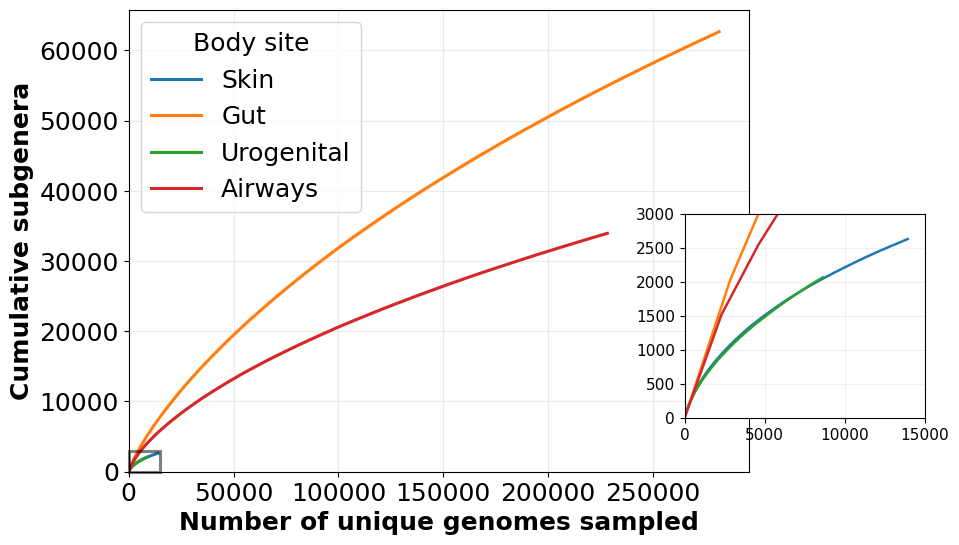

In [8]:
plt.rcParams.update({'font.size': 18})
site_order = [s for s in ["Skin", "Gut", "Urogenital", "Airways"] if s in subgenus_by_body_site_curve["body_site"].unique().to_list()]
colors = {
    "Skin": "#1f77b4",
    "Gut": "#ff7f0e",
    "Urogenital": "#2ca02c",
    "Airways": "#d62728",
}

# Keep the main plot unchanged
fig, ax = plt.subplots(figsize=(8, 6))
for body_site in site_order:
    d = subgenus_by_body_site_curve.filter(pl.col("body_site") == body_site).sort("subset")
    x = d["subset"].to_numpy()
    y_mean = d["mean_subgenera"].to_numpy()
    y_min = d["min_subgenera"].to_numpy()
    y_max = d["max_subgenera"].to_numpy()
    c = colors.get(body_site, None)

    ax.fill_between(x, y_min, y_max, color=c, alpha=0.15, linewidth=0)
    ax.plot(x, y_mean, color=c, lw=2.2, label=body_site)

ax.set_xlabel("Number of unique genomes sampled", fontdict={'fontweight': 'bold'})
ax.set_ylabel("Cumulative subgenera", fontdict={'fontweight': 'bold'})
ax.legend(title="Body site", loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, max(subgenus_by_body_site_curve["subset"].to_list())* 1.05)
ax.set_ylim(0, max(subgenus_by_body_site_curve["max_subgenera"].to_list()) * 1.05)

# Inset placed outside the main axes so it does not change the main plot size
axins = fig.add_axes([0.82, 0.20, 0.30, 0.34])
for body_site in site_order:
    d = subgenus_by_body_site_curve.filter(pl.col("body_site") == body_site).sort("subset")
    x = d["subset"].to_numpy()
    y_mean = d["mean_subgenera"].to_numpy()
    c = colors.get(body_site, None)
    axins.plot(x, y_mean, color=c, lw=1.8)

axins.set_xlim(0, 15000)
axins.set_ylim(0, 3000)
axins.grid(True, alpha=0.2)
axins.tick_params(labelsize=11)

# Add highlighting box + connectors for zoomed region
rect, connectors = ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2.2)
rect.set_facecolor("none")
rect.set_linewidth(2.2)
rect.set_edgecolor("black")
for conn in connectors:
    conn.set_linewidth(1.8)
    conn.set_color("black")

plt.show()

In [9]:
import polars as pl
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Species accumulation curves split by body site
# ---------------------------------------------------------
body_site_species_df = (
    combined
    .select(["seqhash_rep", "body_site", "subfamily_cluster_id"])
    .filter(
        pl.col("body_site").is_not_null()
        & (pl.col("body_site") != "Other")
        & pl.col("subfamily_cluster_id").is_not_null()
    )
    .unique()
)

body_sites = body_site_species_df["body_site"].unique().to_list()
n_reps = 50
n_points = 100
results = []

for body_site in body_sites:
    site_df = body_site_species_df.filter(pl.col("body_site") == body_site)
    n_units = site_df.height
    if n_units == 0:
        continue

    subset_sizes = np.unique(np.linspace(1, n_units, min(n_points, n_units), dtype=int))

    for rep in range(n_reps):
        perm_units = site_df.sample(fraction=1.0, shuffle=True, seed=rep).with_row_index("idx")
        seen_species = set()
        prev_n = 0

        for n in subset_sizes:
            current = perm_units.filter((pl.col("idx") >= prev_n) & (pl.col("idx") < n))
            seen_species.update(current["subfamily_cluster_id"].to_list())
            prev_n = n

            results.append({
                "body_site": body_site,
                "subset": int(n),
                "replicate": rep,
                "species": len(seen_species),
            })

subfamily_by_body_site_curve = (
    pl.from_dicts(results)
    .group_by(["body_site", "subset"])
    .agg([
        pl.col("species").mean().alias("mean_subfamily"),
        pl.col("species").min().alias("min_subfamily"),
        pl.col("species").max().alias("max_subfamily"),
    ])
    .sort(["body_site", "subset"])
)

/tmp/ipykernel_65505/900851996.py:52: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2.2)


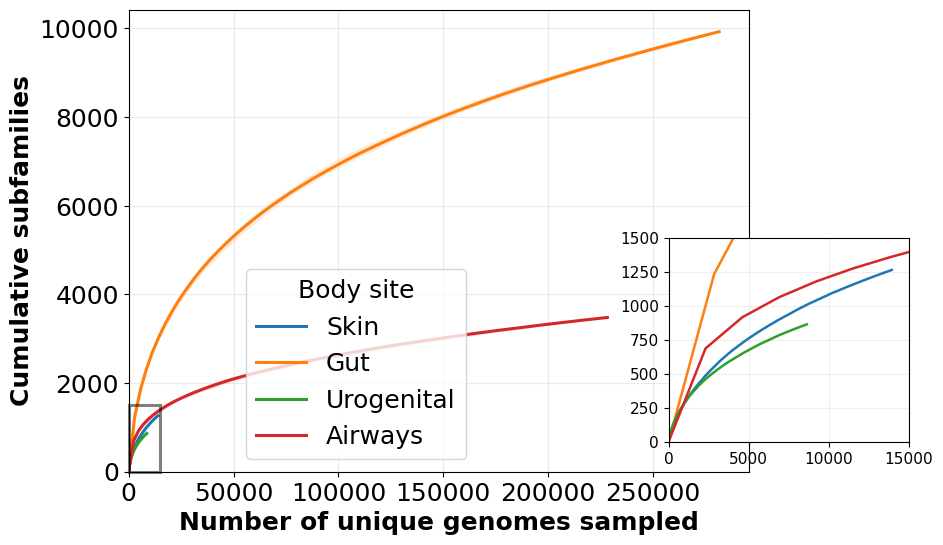

In [17]:
plt.rcParams.update({'font.size': 18})
site_order = [s for s in ["Skin", "Gut", "Urogenital", "Airways"] if s in subfamily_by_body_site_curve["body_site"].unique().to_list()]
colors = {
    "Skin": "#1f77b4",
    "Gut": "#ff7f0e",
    "Urogenital": "#2ca02c",
    "Airways": "#d62728",
}

# Keep the main plot unchanged
fig, ax = plt.subplots(figsize=(8, 6))
for body_site in site_order:
    d = subfamily_by_body_site_curve.filter(pl.col("body_site") == body_site).sort("subset")
    x = d["subset"].to_numpy()
    y_mean = d["mean_subfamily"].to_numpy()
    y_min = d["min_subfamily"].to_numpy()
    y_max = d["max_subfamily"].to_numpy()
    c = colors.get(body_site, None)

    ax.fill_between(x, y_min, y_max, color=c, alpha=0.15, linewidth=0)
    ax.plot(x, y_mean, color=c, lw=2.2, label=body_site)

ax.set_xlabel("Number of unique genomes sampled", fontdict={'fontweight': 'bold'})
ax.set_ylabel("Cumulative subfamilies", fontdict={'fontweight': 'bold'})
ax.grid(True, alpha=0.25)
ax.set_xlim(0, max(subfamily_by_body_site_curve["subset"].to_list())*1.05)
ax.set_ylim(0, max(subfamily_by_body_site_curve["max_subfamily"].to_list()) * 1.05)

# Place the legend lower; anchor its left edge at x=50000 in data coordinates
ax.legend(
    title="Body site",
    loc="lower left",
    bbox_to_anchor=(50000, 0.02),
    bbox_transform=ax.transData,
)

# Inset placed outside the main axes so it does not change the main plot size
axins = fig.add_axes([0.8, 0.16, 0.30, 0.34])
for body_site in site_order:
    d = subfamily_by_body_site_curve.filter(pl.col("body_site") == body_site).sort("subset")
    x = d["subset"].to_numpy()
    y_mean = d["mean_subfamily"].to_numpy()
    c = colors.get(body_site, None)
    axins.plot(x, y_mean, color=c, lw=1.8)

axins.set_xlim(0, 15000)
axins.set_ylim(0, 1500)
axins.grid(True, alpha=0.2)
axins.tick_params(labelsize=11)

# Add highlighting box + connectors for zoomed region
rect, connectors = ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2.2)
rect.set_facecolor("none")
rect.set_linewidth(2.2)
rect.set_edgecolor("black")
for conn in connectors:
    conn.set_linewidth(1.8)
    conn.set_color("black")

plt.show()